# Análise de Desempenho e Perfil Socioemocional - Alfabetização
**Objetivo:** Analisar os resultados da Formativa 1, cruzando com dados de frequência, idade e avaliação socioemocional de entrada para traçar estratégias pedagógicas.

## Etapa 1: Preparação, Limpeza de Dados e Engenharia de Atributos
Nesta etapa, vamos importar as bibliotecas necessárias, carregar os dados e aplicar as regras de negócio definidas:
1. Remover alfabetizandos com status 'EVADIDO'.
2. Remover a turma fictícia 'TURMA-P0000247-0001'.
3. Calcular a Idade, a Taxa de Frequência e extrair o Nível da Formativa 1 de forma limpa.

In [73]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configurações visuais do Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Carregamento dos dados
df = pd.read_csv('data_files/public_data/dados_pedagogicos_22062029.csv')

# 2. Limpeza de Dados (Regras de Negócio)
print(f"Total de registros originais: {df.shape[0]}")

# Removendo EVADIDOS e a Turma Fictícia
df_clean = df[(df['status_alfabetizando'] != 'EVADIDO') & 
              (df['turma'] != 'TURMA-P0000247-0001')].copy()

print(f"Total de registros após limpeza: {df_clean.shape[0]}")

# 3. Engenharia de Atributos (Feature Engineering)

# a) Cálculo da Idade (Considerando a data atual do sistema como ref: 2026)
df_clean['dt_nascimento'] = pd.to_datetime(df_clean['dt_nascimento'], format='%d/%m/%Y', errors='coerce')
data_atual = pd.to_datetime('2026-06-22')
df_clean['idade'] = np.floor((data_atual.year - df_clean['dt_nascimento'].dt.year))

# b) Cálculo da Taxa de Frequência (%)
# Preenchendo nulos com 0 temporariamente para o cálculo, caso não haja aula dada
df_clean['taxa_frequencia'] = (df_clean['qtd_presenca_alfabetizando'] / df_clean['qtd_aulas_dadas_turma']) * 100
# Tratando possíveis divisões por zero ou valores acima de 100% por erro de digitação
df_clean['taxa_frequencia'] = df_clean['taxa_frequencia'].apply(lambda x: 100 if x > 100 else x)

# c) Limpeza da coluna Formativa 1 (Extraindo apenas N1, N2, N3, etc.)
# O formato original é algo como "N1 | Texto explicativo"
df_clean['nivel_forma_1'] = df_clean['forma_1_result'].astype(str).str[:2]
# Substituindo 'na' (nulos) por NaN real
df_clean['nivel_forma_1'] = df_clean['nivel_forma_1'].replace('na', np.nan)

df_clean.head(3)


Total de registros originais: 3507
Total de registros após limpeza: 2620


,cpf,alfabetizando,dt_nascimento,turma,turma_municipio,status_alfabetizando,dt_inicio_turma,alfabetizador,coordenador,qtd_aulas_dadas_turma,...,socio_said_q4,socio_said_q5,socio_said_q6,socio_said_q7,socio_said_q8,socio_said_q9,socio_said_result,idade,taxa_frequencia,nivel_forma_1
11,506.349.187-10,Gabriel Freitas,2008-09-05,TURMA-28002970-0001,Porto da Folha,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0,61.290323,N4
12,723.451.698-00,Dr. Rhavi Moura,1997-09-23,TURMA-28002970-0001,Porto da Folha,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.0,51.612903,N4
13,609.712.853-30,Gael Henrique das Neves,1977-09-26,TURMA-28002970-0001,Porto da Folha,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.0,96.774194,N4


In [74]:
# Removemos colchetes, aspas duplas, aspas simples da coluna socio_entr_q9 e depois dividimos por vírgula
# 1. Criamos uma função inteligente para transformar o texto em uma lista real do Python
def extrair_lista_q9(valor):
    # Se o valor for vazio (NaN), retorna lista vazia
    if pd.isna(valor):
        return []
    
    # Se por acaso já for uma lista, ótimo, apenas retorna
    if isinstance(valor, list):
        return valor
    
    # Limpa espaços em branco nas bordas
    texto = str(valor).strip()
    
    if not texto or texto.lower() == 'nan':
        return []
    
    try:
        # O json.loads pega '["Falta de confian\u00e7a em si"]' e transforma perfeitamente na lista ['Falta de confiança em si']
        # Caso o CSV tenha duplicado aspas (ex: "[""...""]"), corrigimos antes
        texto = texto.replace('""', '"')
        lista = json.loads(texto)
        
        # Retorna a lista garantindo que não há itens vazios soltos
        return [str(item).strip() for item in lista if str(item).strip()]
    except:
        # PLANO B: Se o json falhar por algum caractere estranho, limpamos na mão
        limpo = texto.replace('[', '').replace(']', '').replace('"', '').replace("'", "")
        return [item.strip() for item in limpo.split(',') if item.strip()]
    
# 2. Aplicamos a nossa função na coluna para criar a coluna com as listas reais
df_clean['socio_entr_q8_resum'] = df_clean['socio_entr_q9'].apply(extrair_lista_q9)

# Verificando os tipos de dados e informações das colunas
print(df_clean.info())
display(df_clean.head())
display(df_clean[['socio_entr_q9', 'socio_entr_q8_resum']].head())
print(df_clean['socio_entr_q8_resum'].value_counts())


<class 'pandas.core.frame.DataFrame'>
Index: 2620 entries, 11 to 3506
Data columns (total 71 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   cpf                         2620 non-null   object        
 1   alfabetizando               2620 non-null   object        
 2   dt_nascimento               2613 non-null   datetime64[ns]
 3   turma                       2620 non-null   object        
 4   turma_municipio             2620 non-null   object        
 5   status_alfabetizando        2620 non-null   object        
 6   dt_inicio_turma             2620 non-null   object        
 7   alfabetizador               2620 non-null   object        
 8   coordenador                 2620 non-null   object        
 9   qtd_aulas_dadas_turma       2620 non-null   int64         
 10  qtd_presenca_alfabetizando  2619 non-null   float64       
 11  diag_entr_q1                2618 non-null   float64       
 

,cpf,alfabetizando,dt_nascimento,turma,turma_municipio,status_alfabetizando,dt_inicio_turma,alfabetizador,coordenador,qtd_aulas_dadas_turma,...,socio_said_q5,socio_said_q6,socio_said_q7,socio_said_q8,socio_said_q9,socio_said_result,idade,taxa_frequencia,nivel_forma_1,socio_entr_q8_resum
11,506.349.187-10,Gabriel Freitas,2008-09-05,TURMA-28002970-0001,Porto da Folha,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,31,...,NaN,NaN,NaN,NaN,NaN,NaN,18.0,61.290323,N4,"[Dificuldade ao falar, Habilidades motoras]"
12,723.451.698-00,Dr. Rhavi Moura,1997-09-23,TURMA-28002970-0001,Porto da Folha,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,31,...,NaN,NaN,NaN,NaN,NaN,NaN,29.0,51.612903,N4,[Habilidades motoras]
13,609.712.853-30,Gael Henrique das Neves,1977-09-26,TURMA-28002970-0001,Porto da Folha,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,31,...,NaN,NaN,NaN,NaN,NaN,NaN,49.0,96.774194,N4,[Dificuldade ao falar]
14,198.450.327-88,Breno Carvalho,1995-05-25,TURMA-28002970-0001,Porto da Folha,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,31,...,NaN,NaN,NaN,NaN,NaN,NaN,31.0,100.000000,N4,[Dificuldade ao falar]
15,842.316.579-55,Leandro Cunha,1986-04-26,TURMA-28002970-0001,Porto da Folha,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,31,...,NaN,NaN,NaN,NaN,NaN,NaN,40.0,87.096774,N3,[Dificuldade ao falar]


,socio_entr_q9,socio_entr_q8_resum
11,"[""Dificuldade ao falar"",""Habilidades motoras""]","[Dificuldade ao falar, Habilidades motoras]"
12,"[""Habilidades motoras""]",[Habilidades motoras]
13,"[""Dificuldade ao falar""]",[Dificuldade ao falar]
14,"[""Dificuldade ao falar""]",[Dificuldade ao falar]
15,"[""Dificuldade ao falar""]",[Dificuldade ao falar]


socio_entr_q8_resum
[]                                                                                                                                                                         542
[Dificuldade ao falar]                                                                                                                                                     279
[Falta de confian\u00e7a em si]                                                                                                                                            238
[Habilidades motoras]                                                                                                                                                      163
[Necessidade de maior flexibilidade nos hor\u00e1rios]                                                                                                                     121
                                                                                                         

In [75]:
# Mapeamento de variáveis categóricas para simplificar visualizações
mapeamento_textos = {
    'Demonstra motivação constante e desejo de continuar estudando': 'Demosntra motivação', 
    'Demonstra interesse, mas com oscilações': 'Demonstra interesse', 
    'Demonstra desmotivação ou desejo de interromper': 'Demonstra desmotivação', 
    'São frequentes e pontuais': 'Frequentes e pontuais', 
    'Frequência regular sem nenhuma falta': 'Frequência sem faltas', 
    'Frequência regular com algumas faltas': 'Frequência com faltas', 
    'Realiza com alguma ajuda': 'Realiza com ajuda', 
    'Realiza com autonomia na maioria das situações': 'Realiza com autonomia',
    'Depende de ajuda constante': 'Depende de ajuda', 
    'Tenta com apoio e incentivo': 'Tenta com apoio',
    'Tenta com iniciativa própria': 'Tenta com iniciativa',
    'Demonstra insegurança e evita tentar': 'Demonstra insegurança', 
    'Persiste e aceita o erro como parte da aprendizagem': 'Persiste e aceita o erro',
    'Persiste, mas demonstra frustração': 'Persiste com frustração',
    'Desiste facilmente': 'Desiste facilmente', 
    'Participa ativamente e coopera com os colegas': 'Participa e coopera',
    'Participa quando estimulado(a)': 'Participa quando estimulado(a)',
    'Evita interações': 'Evita interações', 
    'Reconhece claramente e relata usos práticos': 'Reconhece claramente',
    'Reconhece em algumas situações': 'Reconhece algumas vezes',
    'Não reconhece': 'Não reconhece', 
    'N1 | Não reconhece as letras do alfabeto': 'N1',
    'N2 | Lê e registra algumas letras com ajuda, sem relação entre fala e escrita': 'N2',
    'N3 | Reconhece algumas letras do alfabeto': 'N3',
    'N4 | Identifica o número de sílabas de palavras com apoio': 'N4', 
    'N1 | Atenção à escuta e reconhecimento inicial de letras': 'N1', 
    'N2 | Reconhece letras e sílabas com apoio': 'N2',
    'N3 | Identifica sílabas, sem relação letra–som': 'N3',
    'N4 | Reconhece sílabas, sem leitura de palavras': 'N4'
}

cols_categoricas = [
    "status_alfabetizando", "diag_entr_result",
    "socio_entr_q1", "socio_entr_q2", "socio_entr_q3", "socio_entr_q4", 
    "socio_entr_q5", "socio_entr_q6", "socio_entr_q7",
    "forma_1_result", "forma_2_result", "forma_3_result", 
    "forma_4_result", "diag_said_result", 
    "socio_said_q1", "socio_said_q2", "socio_said_q3", "socio_said_q4", 
    "socio_said_q5", "socio_said_q6", "socio_said_q7"
]

# Criar a novas colunas resumidas para cada coluna categórica usando o .map()
for coluna in cols_categoricas:
    df_clean[coluna + '_resum'] = df_clean[coluna].map(mapeamento_textos)

# Transformar em tipo Categórico (ordenado) somente as colunas com níveis
# Isso é importante para que em gráficos o N1 venha antes do N2, etc.
niveis_ordenados = ['N1', 'N2', 'N3', 'N4']
colunas_niveis = ['diag_entr_result_resum', 'forma_1_result_resum', 'forma_2_result_resum', 'forma_3_result_resum', 'forma_4_result_resum', 'diag_said_result_resum']

for coluna in colunas_niveis:
    df_clean[coluna] = pd.Categorical(
        df_clean[coluna], 
        categories=niveis_ordenados, 
        ordered=True
    )

# Removemos colchetes, aspas duplas, aspas simples da coluna socio_entr_q9 e depois dividimos por vírgula
# 1. Criamos uma função inteligente para transformar o texto em uma lista real do Python
def extrair_lista_q9(valor):
    # Se o valor for vazio (NaN), retorna lista vazia
    if pd.isna(valor):
        return []
    
    # Se por acaso já for uma lista, ótimo, apenas retorna
    if isinstance(valor, list):
        return valor
    
    # Limpa espaços em branco nas bordas
    texto = str(valor).strip()
    
    if not texto or texto.lower() == 'nan':
        return []
    
    try:
        # O json.loads pega '["Falta de confian\u00e7a em si"]' e transforma perfeitamente na lista ['Falta de confiança em si']
        # Caso o CSV tenha duplicado aspas (ex: "[""...""]"), corrigimos antes
        texto = texto.replace('""', '"')
        lista = json.loads(texto)
        
        # Retorna a lista garantindo que não há itens vazios soltos
        return [str(item).strip() for item in lista if str(item).strip()]
    except:
        # PLANO B: Se o json falhar por algum caractere estranho, limpamos na mão
        limpo = texto.replace('[', '').replace(']', '').replace('"', '').replace("'", "")
        return [item.strip() for item in limpo.split(',') if item.strip()]
    
# 2. Aplicamos a nossa função na coluna para criar a coluna com as listas reais
df_clean['socio_entr_q8_resum'] = df_clean['socio_entr_q9'].apply(extrair_lista_q9)

# Verificando os tipos de dados e informações das colunas
print(df_clean.info())
display(df_clean.head())
display(df_clean[['socio_entr_q9', 'socio_entr_q8_resum']].head())
print(df_clean['socio_entr_q8_resum'].value_counts())


<class 'pandas.core.frame.DataFrame'>
Index: 2620 entries, 11 to 3506
Data columns (total 92 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   cpf                         2620 non-null   object        
 1   alfabetizando               2620 non-null   object        
 2   dt_nascimento               2613 non-null   datetime64[ns]
 3   turma                       2620 non-null   object        
 4   turma_municipio             2620 non-null   object        
 5   status_alfabetizando        2620 non-null   object        
 6   dt_inicio_turma             2620 non-null   object        
 7   alfabetizador               2620 non-null   object        
 8   coordenador                 2620 non-null   object        
 9   qtd_aulas_dadas_turma       2620 non-null   int64         
 10  qtd_presenca_alfabetizando  2619 non-null   float64       
 11  diag_entr_q1                2618 non-null   float64       
 

,cpf,alfabetizando,dt_nascimento,turma,turma_municipio,status_alfabetizando,dt_inicio_turma,alfabetizador,coordenador,qtd_aulas_dadas_turma,...,forma_3_result_resum,forma_4_result_resum,diag_said_result_resum,socio_said_q1_resum,socio_said_q2_resum,socio_said_q3_resum,socio_said_q4_resum,socio_said_q5_resum,socio_said_q6_resum,socio_said_q7_resum
11,506.349.187-10,Gabriel Freitas,2008-09-05,TURMA-28002970-0001,Porto da Folha,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,723.451.698-00,Dr. Rhavi Moura,1997-09-23,TURMA-28002970-0001,Porto da Folha,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,609.712.853-30,Gael Henrique das Neves,1977-09-26,TURMA-28002970-0001,Porto da Folha,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,198.450.327-88,Breno Carvalho,1995-05-25,TURMA-28002970-0001,Porto da Folha,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,842.316.579-55,Leandro Cunha,1986-04-26,TURMA-28002970-0001,Porto da Folha,CURSANDO,27/04/2026,Luiz Fernando Jesus,Ana Sophia Aragão,31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,socio_entr_q9,socio_entr_q8_resum
11,"[""Dificuldade ao falar"",""Habilidades motoras""]","[Dificuldade ao falar, Habilidades motoras]"
12,"[""Habilidades motoras""]",[Habilidades motoras]
13,"[""Dificuldade ao falar""]",[Dificuldade ao falar]
14,"[""Dificuldade ao falar""]",[Dificuldade ao falar]
15,"[""Dificuldade ao falar""]",[Dificuldade ao falar]


socio_entr_q8_resum
[]                                                                                                                                                                         542
[Dificuldade ao falar]                                                                                                                                                     279
[Falta de confian\u00e7a em si]                                                                                                                                            238
[Habilidades motoras]                                                                                                                                                      163
[Necessidade de maior flexibilidade nos hor\u00e1rios]                                                                                                                     121
                                                                                                         

## Pergunta 1: Características do Perfil de Risco (N1 e N2 na Formativa 1)
**Análise:** Considerando somente os alfabetizandos N1 ou N2 na Formativa 1, vamos verificar os resultados da Atividade Socioemocional, a frequência e a idade.

Total de alunos classificados como N1 ou N2: 1113


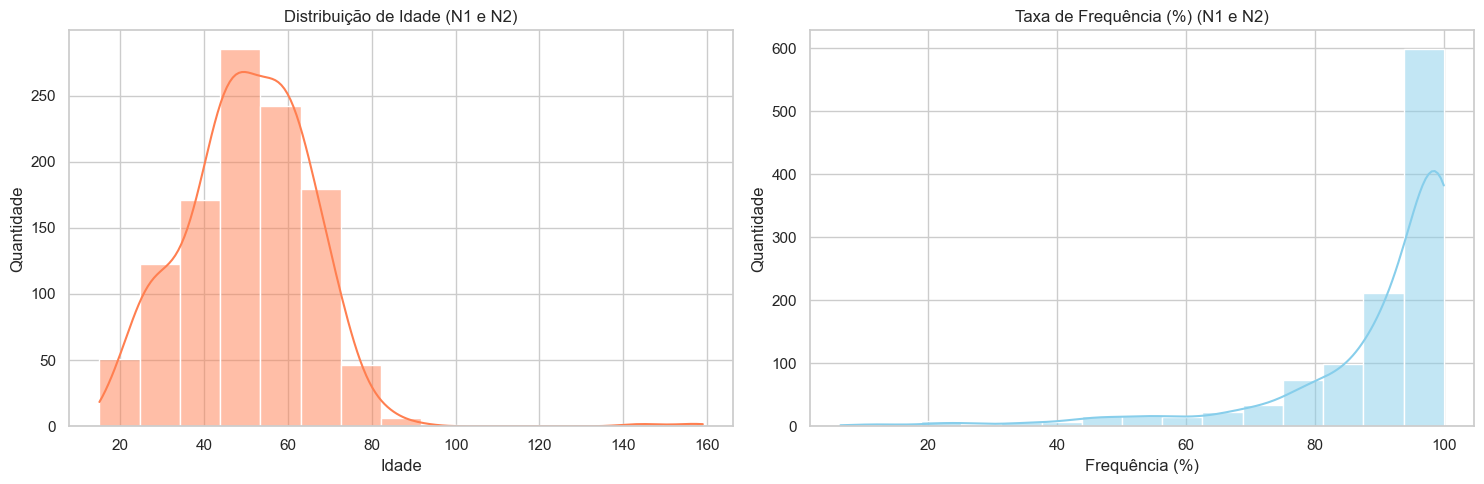


--- Resumo Estatístico (N1 e N2) ---
Idade Média: 50.5 anos
Frequência Média: 90.1%


In [76]:
# Filtrando alfabetizandos N1 e N2
df_n1_n2 = df_clean[df_clean['nivel_forma_1'].isin(['N1', 'N2'])].copy()

print(f"Total de alunos classificados como N1 ou N2: {df_n1_n2.shape[0]}")

# --- Análise de Idade e Frequência ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribuição de Idade
sns.histplot(df_n1_n2['idade'], bins=15, kde=True, ax=axes[0], color='coral')
axes[0].set_title('Distribuição de Idade (N1 e N2)')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Quantidade')

# Distribuição de Frequência
sns.histplot(df_n1_n2['taxa_frequencia'], bins=15, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Taxa de Frequência (%) (N1 e N2)')
axes[1].set_xlabel('Frequência (%)')
axes[1].set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

print("\n--- Resumo Estatístico (N1 e N2) ---")
print(f"Idade Média: {df_n1_n2['idade'].mean():.1f} anos")
print(f"Frequência Média: {df_n1_n2['taxa_frequencia'].mean():.1f}%")


Analisando a coluna: socio_entr_q1_resum
socio_entr_q1_resum
Demosntra motivação       768
Demonstra interesse       280
Demonstra desmotivação     65
Name: count, dtype: int64
Total de respospostas válidas: 1113
--------------------------------------------------
Analisando a coluna: socio_entr_q2_resum
socio_entr_q2_resum
Frequentes e pontuais    492
Frequência sem faltas    344
Frequência com faltas    277
Name: count, dtype: int64
Total de respospostas válidas: 1113
--------------------------------------------------
Analisando a coluna: socio_entr_q3_resum
socio_entr_q3_resum
Realiza com ajuda        569
Depende de ajuda         333
Realiza com autonomia    211
Name: count, dtype: int64
Total de respospostas válidas: 1113
--------------------------------------------------
Analisando a coluna: socio_entr_q4_resum
socio_entr_q4_resum
Tenta com apoio          684
Tenta com iniciativa     289
Demonstra insegurança    140
Name: count, dtype: int64
Total de respospostas válidas: 1113
----

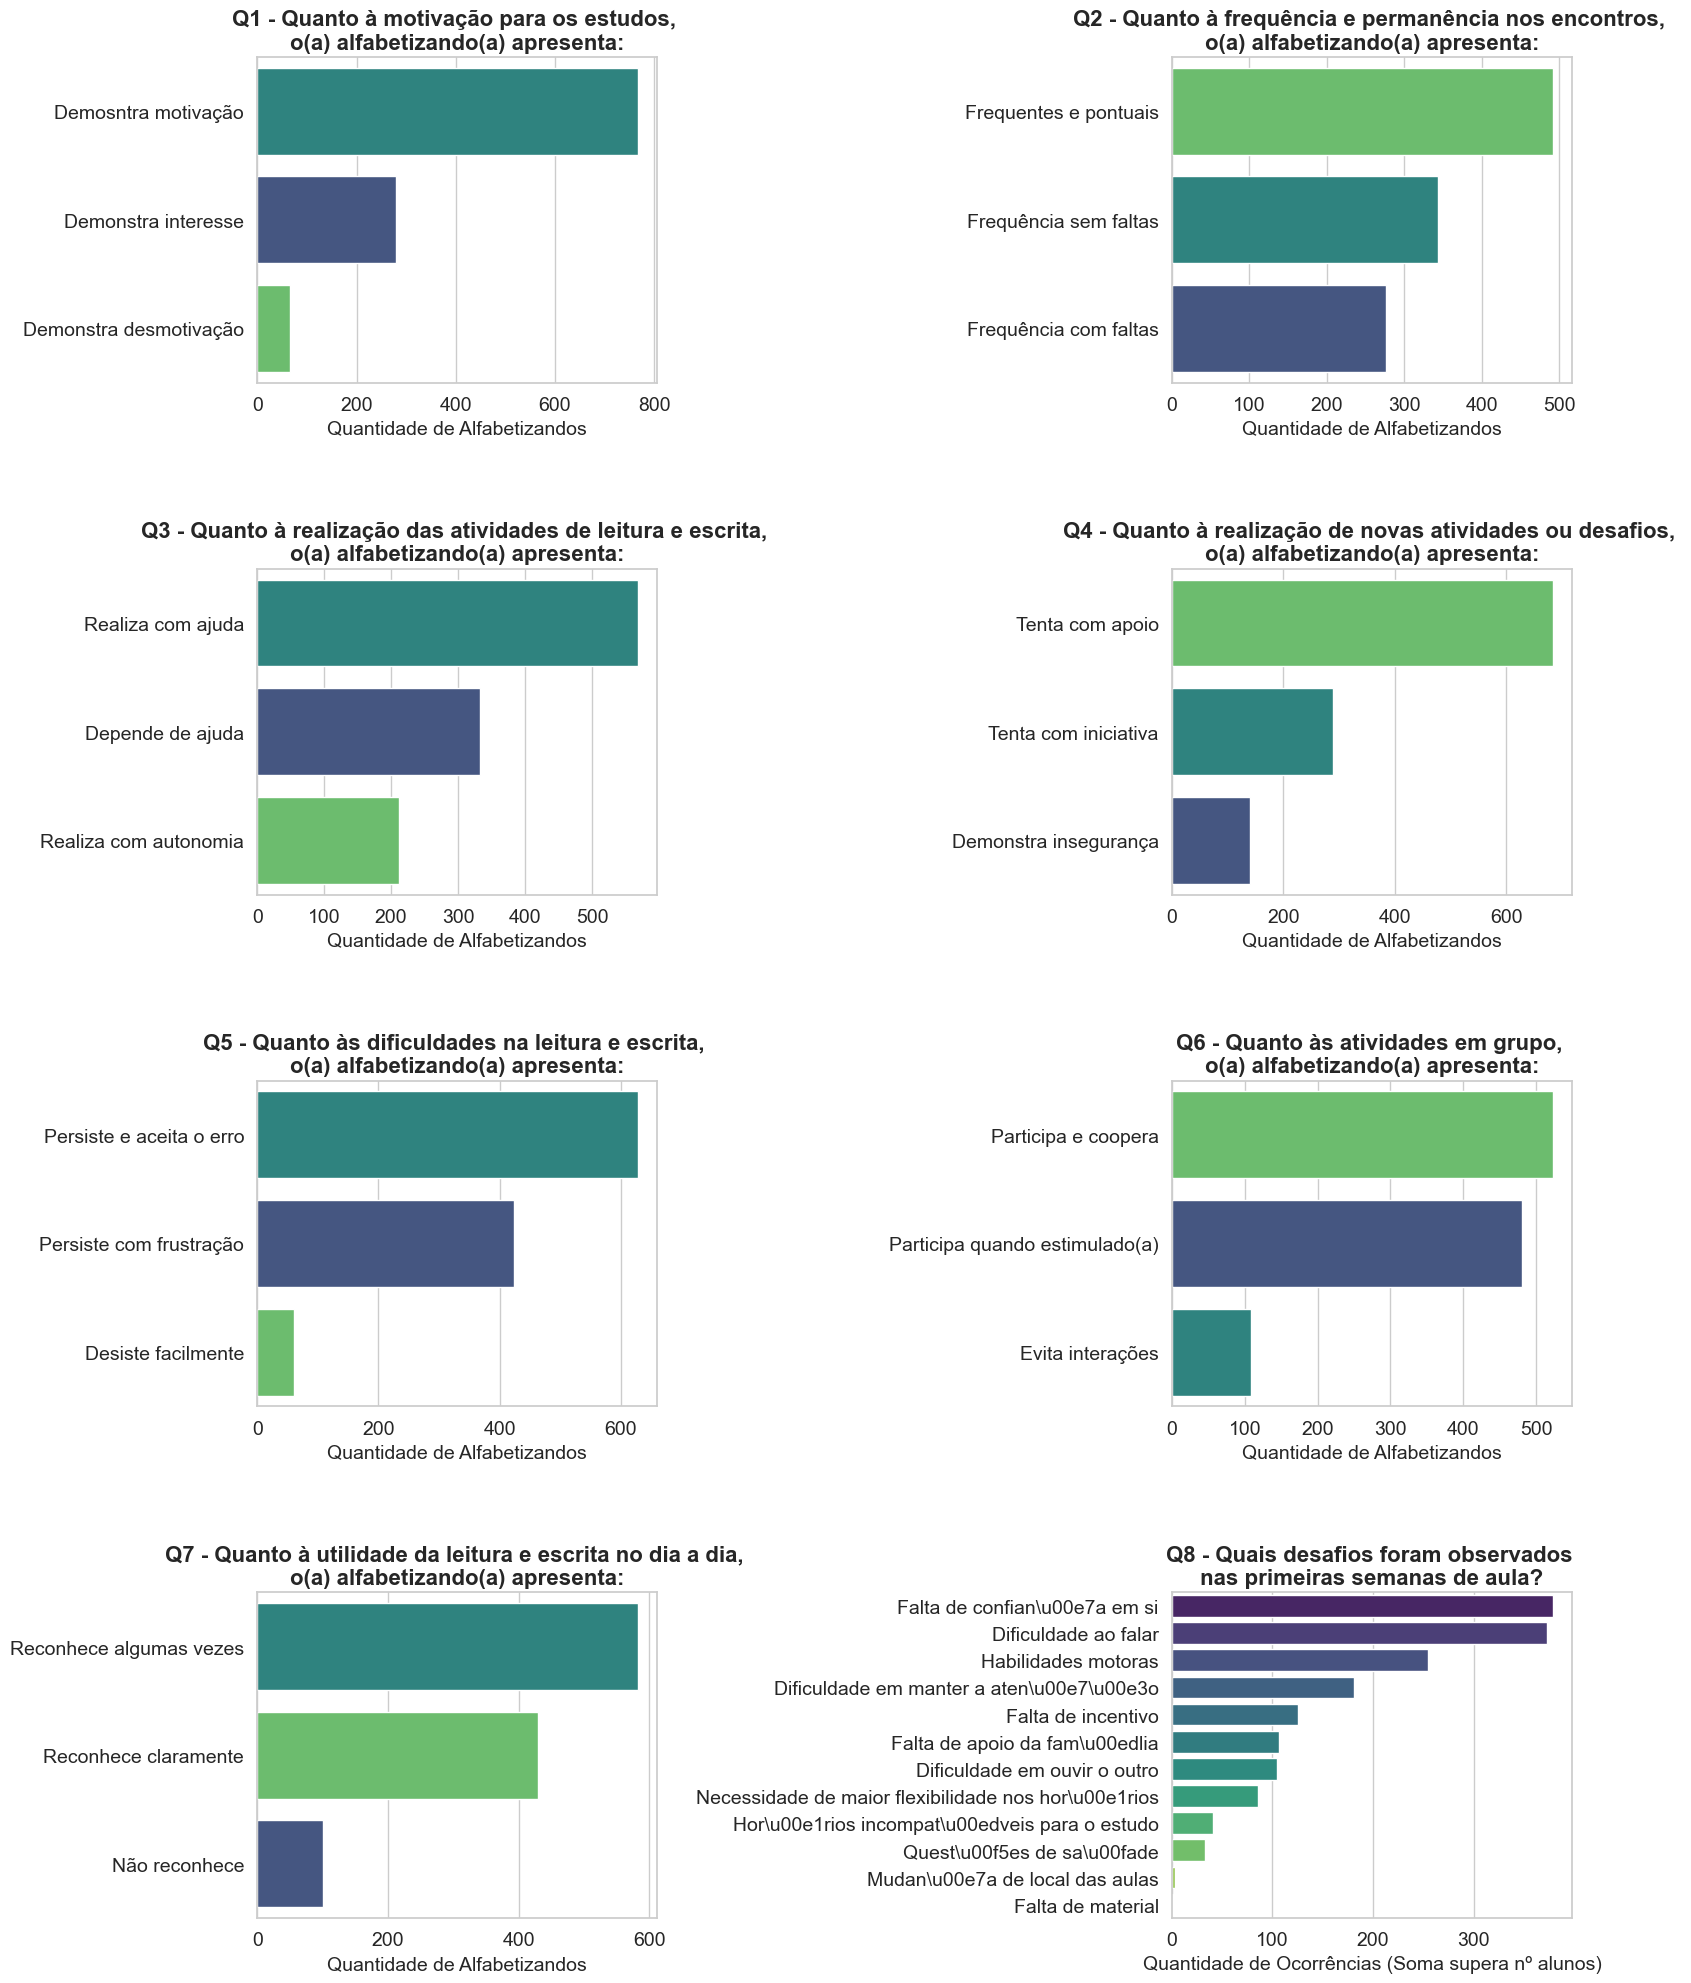

In [77]:
# Construindo dicionário com o enunciado de cada questão da Socioemocional
dicionario_questoes_socio = {
    'socio_entr_q1_resum': 'Q1 - Quanto à motivação para os estudos, \no(a) alfabetizando(a) apresenta:',
    'socio_entr_q2_resum': 'Q2 - Quanto à frequência e permanência nos encontros, \no(a) alfabetizando(a) apresenta:',
    'socio_entr_q3_resum': 'Q3 - Quanto à realização das atividades de leitura e escrita, \no(a) alfabetizando(a) apresenta:',
    'socio_entr_q4_resum': 'Q4 - Quanto à realização de novas atividades ou desafios, \no(a) alfabetizando(a) apresenta:',
    'socio_entr_q5_resum': 'Q5 - Quanto às dificuldades na leitura e escrita, \no(a) alfabetizando(a) apresenta:',
    'socio_entr_q6_resum': 'Q6 - Quanto às atividades em grupo, \no(a) alfabetizando(a) apresenta:',
    'socio_entr_q7_resum': 'Q7 - Quanto à utilidade da leitura e escrita no dia a dia, \no(a) alfabetizando(a) apresenta:'
}

# Configurando estilo dos gráficos
sns.set_theme(style="whitegrid")

# Definindo as colunas (vamos pegar da 1 a 7 para o loop automático)
socio_cols = [f'socio_entr_q{i}_resum' for i in range(1, 8)]

# Entendendo número de respostas válidas para cada questão da socioemocional
for col in socio_cols:
    if col in df_n1_n2.columns and df_n1_n2[col].notna().sum() > 0:
        print(f"Analisando a coluna: {col}")
        print(df_n1_n2[col].value_counts())
        print(f"Total de respospostas válidas: {df_n1_n2[col].count()}")
        print("-"*50)

# 1. Filtrar dinamicamente as colunas de 1 a 7 que possuem dados
cols_com_dados = [
    col for col in socio_cols 
    if col in df_n1_n2.columns and df_n1_n2[col].notna().sum() > 0
]

# 2. Criando a grade fixa de 4 linhas e 2 colunas (8 espaços totais)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))
axes = axes.flatten()

# 3. Loop para desenhar as 7 primeiras questões
for i, col in enumerate(cols_com_dados):
    sns.countplot(
        y=col, 
        data=df_n1_n2, 
        order=df_n1_n2[col].value_counts().index, 
        palette='viridis', 
        hue=col,            
        legend=False,       
        ax=axes[i]
    )
    
    titulo = dicionario_questoes_socio.get(col, col)
    axes[i].set_title(titulo, fontsize=16, fontweight='bold')
    axes[i].set_xlabel('Quantidade de Alfabetizandos', fontsize=14)
    axes[i].set_ylabel('', fontsize=14)
    axes[i].tick_params(axis='y', labelsize=14)
    axes[i].tick_params(axis='x', labelsize=14)

# =====================================================================
# 4. INSERINDO A QUESTÃO 8 NO ÚLTIMO ESPAÇO DA GRADE (Índice 7)
# =====================================================================
# ATENÇÃO: Substitua "socio_entr_q8_resum" abaixo pelo nome exato 
# da variável onde está a sua contagem (a Series que você colou acima).

# Fazemos o "Explode": separa a lista criando uma linha para cada resposta dada
df_q8_explodido = df_n1_n2.explode('socio_entr_q8_resum')

# Removemos qualquer linha que tenha ficado vazia após o explode
df_q8_explodido = df_q8_explodido.dropna(subset=['socio_entr_q8_resum'])
df_q8_explodido = df_q8_explodido[df_q8_explodido['socio_entr_q8_resum'] != '']

# Contamos a frequência real de cada alternativa
contagem_q8 = df_q8_explodido['socio_entr_q8_resum'].value_counts()

print(contagem_q8)

variavel_contagem_q8 = contagem_q8.copy() 

sns.barplot(
    x=variavel_contagem_q8.values, 
    y=variavel_contagem_q8.index, 
    palette='viridis',
    hue=variavel_contagem_q8.index,
    legend=False,
    ax=axes[7] # axes[7] é o 8º e último quadrado!
)

# Configurando o título da Q8
titulo_q8 = 'Q8 - Quais desafios foram observados \nnas primeiras semanas de aula?'
axes[7].set_title(titulo_q8, fontsize=16, fontweight='bold')
axes[7].set_xlabel('Quantidade de Ocorrências (Soma supera nº alunos)', fontsize=14)
axes[7].set_ylabel('', fontsize=14)
axes[7].tick_params(axis='y', labelsize=14)
axes[7].tick_params(axis='x', labelsize=14)

# =====================================================================

# Ajuste do layout
plt.tight_layout(h_pad=5.0, w_pad=2.0)
plt.show()


## Pergunta 2: Turmas com maioria (Moda) em N1 e N2 na Formativa 1
**Análise:** Vamos identificar quais turmas possuem gargalo coletivo, ou seja, onde o nível que mais se repete (moda) é N1 ou N2.

In [78]:
# Função para pegar a moda com segurança
def get_moda(series):
    modas = series.dropna().mode()
    return modas.iloc[0] if not modas.empty else None

# Agrupando por turma e calculando a moda da Formativa 1
turmas_moda = df_clean.groupby(['turma', 'turma_municipio'])['nivel_forma_1'].apply(get_moda).reset_index()

# Filtrando turmas onde a moda é N1 ou N2
turmas_criticas = turmas_moda[turmas_moda['nivel_forma_1'].isin(['N1', 'N2'])]

qtd_turmas_criticas = len(turmas_criticas)
qtd_turmas_total = len(turmas_moda)

print(f"Total de turmas analisadas: {qtd_turmas_total}")
print(f"Quantidade de turmas com moda em N1 ou N2: {qtd_turmas_criticas} ({(qtd_turmas_criticas/qtd_turmas_total)*100:.1f}%)")
print("\nLista das turmas críticas:")
display(turmas_criticas.sort_values(by=['turma_municipio', 'turma']).reset_index(drop=True))

# Salvando a lista de turmas críticas para a próxima etapa
lista_turmas_criticas = turmas_criticas['turma'].tolist()

Total de turmas analisadas: 137
Quantidade de turmas com moda em N1 ou N2: 54 (39.4%)

Lista das turmas críticas:


,turma,turma_municipio,nivel_forma_1
0,TURMA-28018389-0001,Aracaju,N2
1,TURMA-28018575-0001,Aracaju,N2
2,TURMA-P0000241-0001,Aracaju,N1
3,TURMA-P0000241-0002,Aracaju,N1
4,TURMA-P0000245-0001,Aracaju,N1
5,TURMA-28014146-0001,Capela,N2
6,TURMA-28014170-0001,Capela,N2
7,TURMA-28014170-0002,Capela,N2
8,TURMA-28003551-0001,Carira,N2
9,TURMA-P0000244-0001,Carira,N2


## Pergunta 3: A realidade dos alfabetizandos dentro das Turmas Críticas
**Análise:** Agora vamos olhar para o panorama GERAL (todos os alunos, independentemente da nota) que estudam nas turmas identificadas no passo anterior. Como é o ecossistema dessas salas?

Total de alunos inseridos nas turmas críticas: 1081

--- Resumo Estatístico (Ecossistema das Turmas Críticas) ---
Idade Média Geral nestas turmas: 49.2 anos
Frequência Média Geral nestas turmas: 90.4%


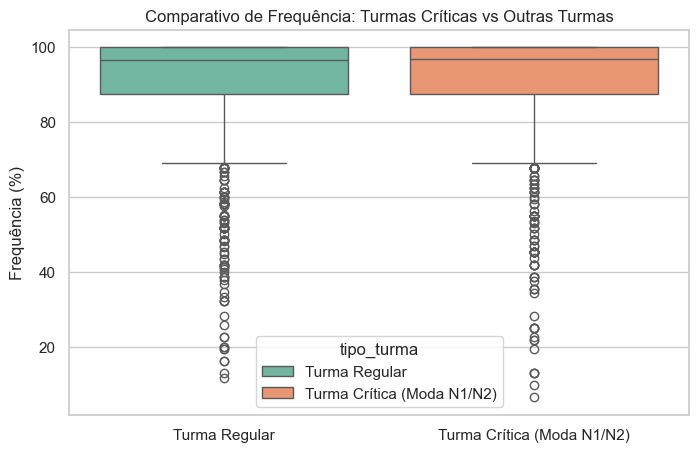

In [81]:
# Filtrando o dataframe original apenas para os alunos que pertencem às turmas críticas
df_ecossistema_critico = df_clean[df_clean['turma'].isin(lista_turmas_criticas)].copy()

print(f"Total de alunos inseridos nas turmas críticas: {df_ecossistema_critico.shape[0]}")

# --- Análise de Idade e Frequência nas Turmas Críticas ---
print("\n--- Resumo Estatístico (Ecossistema das Turmas Críticas) ---")
print(f"Idade Média Geral nestas turmas: {df_ecossistema_critico['idade'].mean():.1f} anos")
print(f"Frequência Média Geral nestas turmas: {df_ecossistema_critico['taxa_frequencia'].mean():.1f}%")

# Gráfico comparativo de Frequência: Turmas Críticas vs Restante
df_clean['tipo_turma'] = np.where(df_clean['turma'].isin(lista_turmas_criticas), 'Turma Crítica (Moda N1/N2)', 'Turma Regular')

plt.figure(figsize=(8, 5))
sns.boxplot(x='tipo_turma', y='taxa_frequencia', data=df_clean, palette='Set2', hue='tipo_turma', legend=True)
plt.title('Comparativo de Frequência: Turmas Críticas vs Outras Turmas')
plt.ylabel('Frequência (%)')
plt.xlabel('')
plt.show()


## Pergunta 4: Estratégias Recomendadas para a Formativa 2 (Aprofundamento)

Para traçar um plano de ação para a **Formativa 2**, as coordenações e alfabetizadores precisam entender as características emocionais e cognitivas atreladas a esse grupo de risco. Nossa análise de todas as questões socioemocionais das "Turmas Críticas" revelou gargalos específicos que exigem estratégias direcionadas:

### 1. Intervenção na Confiança e Dificuldades na Fala (Foco na Q8 e Q9)
* **Achado nos Dados:** Ao olharmos os principais gargalos relatados (Q8), vemos que **"Dificuldade ao falar"**, **"Falta de confiança em si"** e **"Habilidades motoras"** dominam o topo das reclamações nas turmas críticas.
* **Estratégia:**
  * **Pedagógica:** O alfabetizador deve priorizar o uso de espelhos para treino fonoarticulatório (para que o aluno veja como a boca se move ao pronunciar os fonemas). 
  * **Engajamento:** Reduzir drasticamente a leitura individual em voz alta na frente da sala inteira, para não ferir a já fragilizada autoconfiança destes alunos. Substituir por leitura sussurrada em pares.

### 2. Transição Gradual da Dependência para Autonomia (Foco na Q4)
* **Achado nos Dados:** O número de alunos que **"Tenta com apoio e incentivo"** é quase o dobro dos que "Tentam com iniciativa própria". Há um claro padrão de dependência do mediador.
* **Estratégia:**
  * **Andaime Cognitivo:** O alfabetizador deve usar a técnica do "Eu faço, nós fazemos, você faz". Não se pode soltar a atividade e esperar iniciativa. É necessário modelar a tarefa, fazer uma vez com o aluno e, na terceira tentativa, estar apenas como observador.

### 3. Aprendizagem Multissensorial e Concreta (Foco em Q6 e Q3)
* **Achado nos Dados:** Os alunos precisam de ajuda constante/alguma ajuda (Q3), e participam melhor quando estimulados ou colaborando ativamente com colegas (Q6).
* **Estratégia:**
  * **Mão na Massa:** Alunos N1/N2 têm muita dificuldade com abstração (somente olhar para o quadro). O alfabetizador deve usar material concreto: letras móveis, massa de modelar, areia para traçar as letras, jogos de pareamento de imagens com a letra inicial.
  * **Agrupamento Produtivo:** Sentar os alunos N1 e N2 com alunos N3 e N4 (agrupamentos heterogêneos para atividades de cooperação).

### 4. Busca Ativa Preditiva 
* **Achado nos Dados:** A taxa de frequência dos níveis N1 e N2 é, em média, mais volátil (frequência com faltas aparece muito na Q2) e com picos de ausência maiores que as turmas regulares.
* **Estratégia:**
  * Implementar Busca Ativa 48h: Caso o aluno falte duas aulas seguidas, a coordenação já entra em contato direto, para evitar que a defasagem no aprendizado vire abandono.